# Tugas Besar Machine Learning
---  
  
|NPM|Nama|
|--|--|
|6182301013|Bryan Ricaldi Chandra|
|6182301024|Vince Farrel Natanael|
|6182301094|Bima Rahmadani Arifandi  

Berikut Merupakan alasan mengapa kita menganggap topik ini menarik
1. **Relevansi Ekosistem  di Dunia Nyata**

    Dataset ini merepresentasikan masalah operasional nyata pada industri food delivery. Layanan ini sudah menjadi bagian tak terpisahkan dari mobilitas keseharian masyarakat perkotaan, layaknya ekosistem pemesanan makanan yang sering kita gunakan di kota-kota besar seperti Bandung. Menganalisis data ini memberikan gambaran langsung bagaimana perusahaan teknologi besar mengoptimalkan layanan mereka dan memprediksi kesejahteraan mitra pengemudi (melalui analisis tip).
  
2. **Potensi Ekstraksi Insight Finansial dan Perilaku Pelanggan**  
    
    Dataset ini memungkinkan kita menjawab pertanyaan yang bernilai bisnis (sesuai dengan kriteria rubrik Insight & Interpretasi). Beberapa alasan spesifik dari sisi analitis:

    - Keadilan & Kesejahteraan Kurir: Memahami faktor apa yang membuat pelanggan memberikan tip besar dapat digunakan oleh platform untuk merekomendasikan area unggulan bagi para pengemudi.

    - Perilaku Spasial: Adanya fitur Delivery Region (seperti Palo Alto dan Mountain View) memungkinkan kita menganalisis apakah budaya memberi tip atau kecepatan pengiriman dipengaruhi oleh daya beli atau infrastruktur di area tertentu.  

    - Manajemen Kualitas Layanan (SLA) & Retensi Pelanggan: Memprediksi risiko keterlambatan pengiriman (*isLate*) memungkinkan platform untuk mengambil tindakan preventif secara proaktif. Dengan mengetahui pesanan mana yang berpeluang besar terlambat (misalnya memakan waktu > 60 menit), platform dapat mengoptimalkan alokasi kurir, menyesuaikan ekspektasi waktu tiba di aplikasi pelanggan, serta mencegah ulasan buruk atau peralihan pengguna ke layanan kompetitor (*churn*).  

Pada Tugas kali ini terdapat 3 tujuan utama yang kita ingin prediksi

1. Regresi: Memprediksi Amount of Tip
Model ini bertujuan memahami faktor finansial dan operasional yang mendorong pelanggan memberikan jumlah tip lebih besar.
* **Order Total:** Besaran tip umumnya sangat berkorelasi dengan total nilai pesanan. Pesanan dengan nominal besar (seperti pesanan keluarga atau kantor) sering kali memicu pelanggan untuk memberikan proporsi tip yang berbeda dibandingkan pesanan individu skala kecil.
* **Delivery Region:** Wilayah pengiriman mencerminkan demografi dan daya beli pelanggan. Area tertentu (misalnya Palo Alto vs. Mountain View) mungkin memiliki budaya memberikan tip (*tipping culture*) atau tingkat pendapatan rata-rata yang berbeda, sehingga memengaruhi jumlah tip secara spasial.
* **Delivery Time:** Durasi pengiriman adalah indikator utama kepuasan pelanggan. Pengiriman yang cepat dan efisien sering kali dihargai dengan jumlah tip yang lebih tinggi, sementara keterlambatan dapat secara drastis mengurangi keinginan pelanggan untuk memberikan tip.
* **Is ASAP:** Untuk mengetahui apakah pesanan tersebut dijawdwalkan atau tidak

2. Klasifikasi: Memprediksi Risiko Keterlambatan (Late Delivery)
Model ini bertujuan memprediksi apakah sebuah pesanan akan memakan waktu lebih dari 60 menit, yang sangat krusial untuk menjaga *Service Level Agreement (SLA)*.
 Angka 60 menit dipilih karena berdasarkan analisis statistik durasi pengiriman, rata-rata waktu yang dibutuhkan adalah sekitar 58 menit, dan sekitar 30% pesanan memakan waktu lebih dari 60 menit. Ini menjadikannya ambang batas yang realistis untuk mendefinisikan keterlambatan.
* **Order Total:** Total pesanan dapat menjadi proksi untuk ukuran atau kompleksitas makanan yang disiapkan. Pesanan dengan nominal sangat besar umumnya membutuhkan waktu persiapan yang jauh lebih lama di dapur restoran, sehingga meningkatkan risiko keterlambatan pengiriman.
* **Delivery Region:** Memperhitungkan kondisi infrastruktur, jarak tempuh rata-rata, dan kepadatan lalu lintas di berbagai wilayah. Beberapa area mungkin memiliki rute yang lebih rawan macet atau kekurangan ketersediaan mitra pengemudi.
* **Customer Placed Order datetime:** Fitur waktu adalah faktor paling kritis dalam logistik. Jam pemesanan menangkap efek *rush hour* (seperti jam makan siang atau makan malam), sementara hari pemesanan menangkap lonjakan permintaan di akhir pekan yang sering memicu antrean panjang di restoran.
* **Amount of discount:** Adanya diskon atau promo sering kali memicu lonjakan pesanan mendadak. Restoran dan sistem alokasi kurir kerap kewalahan menghadapi lonjakan tiba-tiba ini, yang secara langsung berimbas pada penumpukan pesanan dan keterlambatan.

3. Clustering (Segmentasi): Melakukan Segmentasi Pelanggan/Pesanan menggunakan algoritma (seperti K-Means) berdasarkan nilai transaksi (Order Total) dan jumlah tip.



### 1. Analisis Awal

- Membaca dataset awal
- Menampilkan info tipe data dari setiap fitur
- Menampilkan info statistik awal dari data tersebut

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('dataset.csv')
df.head()

,Customer placed order datetime,Placed order with restaurant datetime,Driver at restaurant datetime,Delivered to consumer datetime,Driver ID,Restaurant ID,Consumer ID,Delivery Region,Is ASAP,Order total,Amount of discount,Amount of tip,Refunded amount
0,01 00:00:47,01 01:44:06,01 01:53:24,01 02:11:35,216,59,5271,Palo Alto,False,32.05,0.0,3.21,0.0
1,01 00:03:15,01 00:07:22,NaN,01 00:28:17,259,83,640,Palo Alto,True,21.12,0.0,1.39,0.0
2,01 00:03:54,01 00:12:37,NaN,01 01:06:19,66,63,25002,Palo Alto,False,110.45,0.0,14.40,0.0
3,01 00:04:46,01 00:07:26,NaN,01 00:49:43,313,83,9923,Palo Alto,True,63.31,0.0,3.17,0.0
4,01 00:04:49,01 00:07:40,01 00:17:50,01 00:46:26,133,86,60072,Palo Alto,True,61.98,0.0,2.57,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18078 entries, 0 to 18077
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer placed order datetime         18078 non-null  str    
 1   Placed order with restaurant datetime  18038 non-null  str    
 2   Driver at restaurant datetime          13547 non-null  str    
 3   Delivered to consumer datetime         18078 non-null  str    
 4   Driver ID                              18078 non-null  int64  
 5   Restaurant ID                          18078 non-null  int64  
 6   Consumer ID                            18078 non-null  int64  
 7   Delivery Region                        18052 non-null  str    
 8   Is ASAP                                18078 non-null  bool   
 9   Order total                            18078 non-null  float64
 10  Amount of discount                     18078 non-null  float64
 11  Amount of tip

In [5]:
df.describe()

,Driver ID,Restaurant ID,Consumer ID,Order total,Amount of discount,Amount of tip,Refunded amount
count,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000
mean,222.448169,108.721263,32010.313475,51.261496,1.356706,3.492022,0.612091
std,105.219194,98.609766,42010.215766,50.599675,6.516667,3.700115,6.073104
min,7.000000,2.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,141.000000,23.000000,4243.500000,26.660000,0.000000,1.400000,0.000000
50%,227.000000,77.000000,10972.000000,38.630000,0.000000,2.550000,0.000000
75%,314.000000,186.000000,56857.000000,57.885000,0.000000,4.460000,0.000000
max,438.000000,409.000000,200449.000000,1604.130000,187.880000,120.300000,414.770000


In [6]:
df.isnull().sum()

Customer placed order datetime              0
Placed order with restaurant datetime      40
Driver at restaurant datetime            4531
Delivered to consumer datetime              0
Driver ID                                   0
Restaurant ID                               0
Consumer ID                                 0
Delivery Region                            26
Is ASAP                                     0
Order total                                 0
Amount of discount                          0
Amount of tip                               0
Refunded amount                             0
dtype: int64

### 1.2 Visualisasi Awal Data
- Menggunakan boxplot untuk mengetahui outlier
- Menggunakan heatmap untuk menunjukan korelasi linear antar fitur

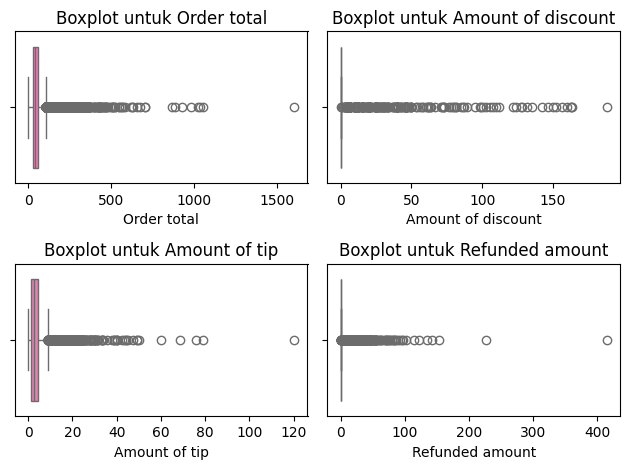

In [7]:
numerical_feature= ['Order total', 'Amount of discount', 'Amount of tip', 'Refunded amount']
for i, col in enumerate(numerical_feature):
  plt.subplot(2, 2, i+1)
  sns.boxplot(x=df[col], color='hotpink')
  plt.title(f'Boxplot untuk {col}')
plt.tight_layout()
plt.show()

**Analisis Boxplot:**

Berdasarkan visualisasi boxplot di atas, kita dapat mengambil beberapa poin penting:
1. **Keberadaan Outlier yang Signifikan**: Pada fitur `Order total` dan `Amount of tip`, terdapat banyak titik di luar *whiskers* atas. Ini menunjukkan adanya pesanan dengan nilai transaksi yang sangat tinggi (mencapai >1500) dan tip yang sangat besar dibandingkan rata-rata pesanan lainnya.
2. **Rentang Nilai (IQR)**: Kotak (Interquartile Range) pada setiap fitur cenderung pendek dan terletak di bagian bawah skala, yang berarti mayoritas data berkumpul di nilai yang relatif kecil.
3. **Refunded Amount**: Fitur ini menunjukkan variasi yang sangat minim, di mana hampir seluruh data berada di nilai 0, menandakan pengembalian dana adalah kejadian yang sangat langka dalam dataset ini.
4. **Implikasi Model**: Banyaknya outlier ini perlu ditangani pada tahap preprocessing (misalnya dengan transformasi log atau pembersihan data) agar tidak mengganggu performa model regresi nantinya.

/tmp/ipykernel_49668/1334723223.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Delivery Region', palette='viridis', order=df['Delivery Region'].value_counts().index)


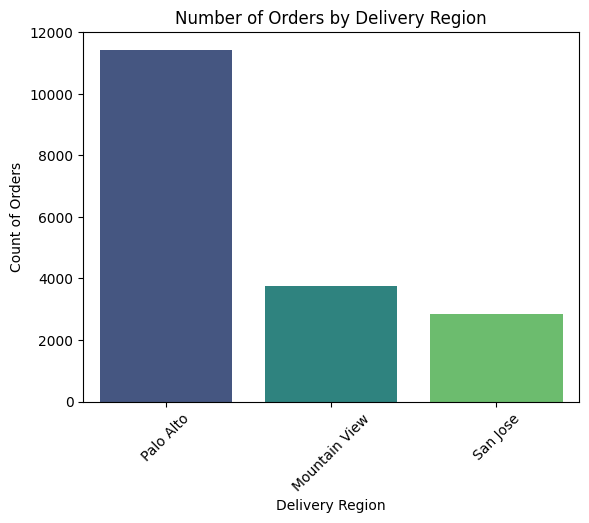

In [8]:
sns.countplot(data=df, x='Delivery Region', palette='viridis', order=df['Delivery Region'].value_counts().index)
plt.title('Number of Orders by Delivery Region')
plt.xlabel('Delivery Region')
plt.ylabel('Count of Orders')
plt.xticks(rotation=45)
plt.show()

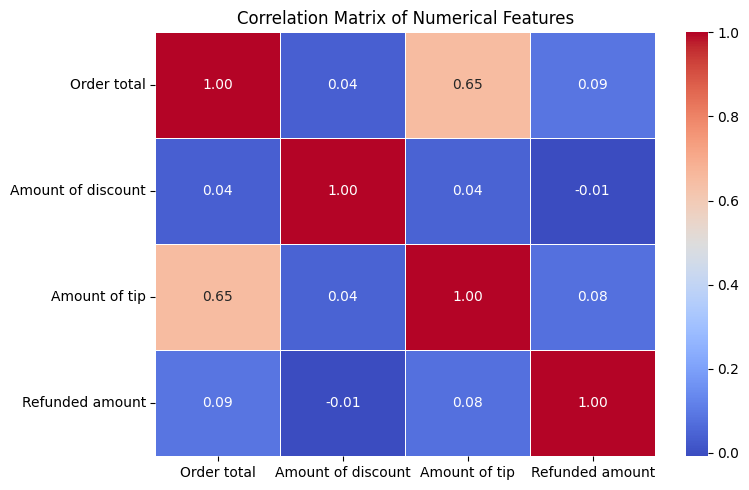

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[numerical_feature].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### 1.3 Distribusi Data (Histogram)
Histogram digunakan untuk melihat sebaran frekuensi dari setiap fitur numerik guna memahami karakteristik data lebih dalam.

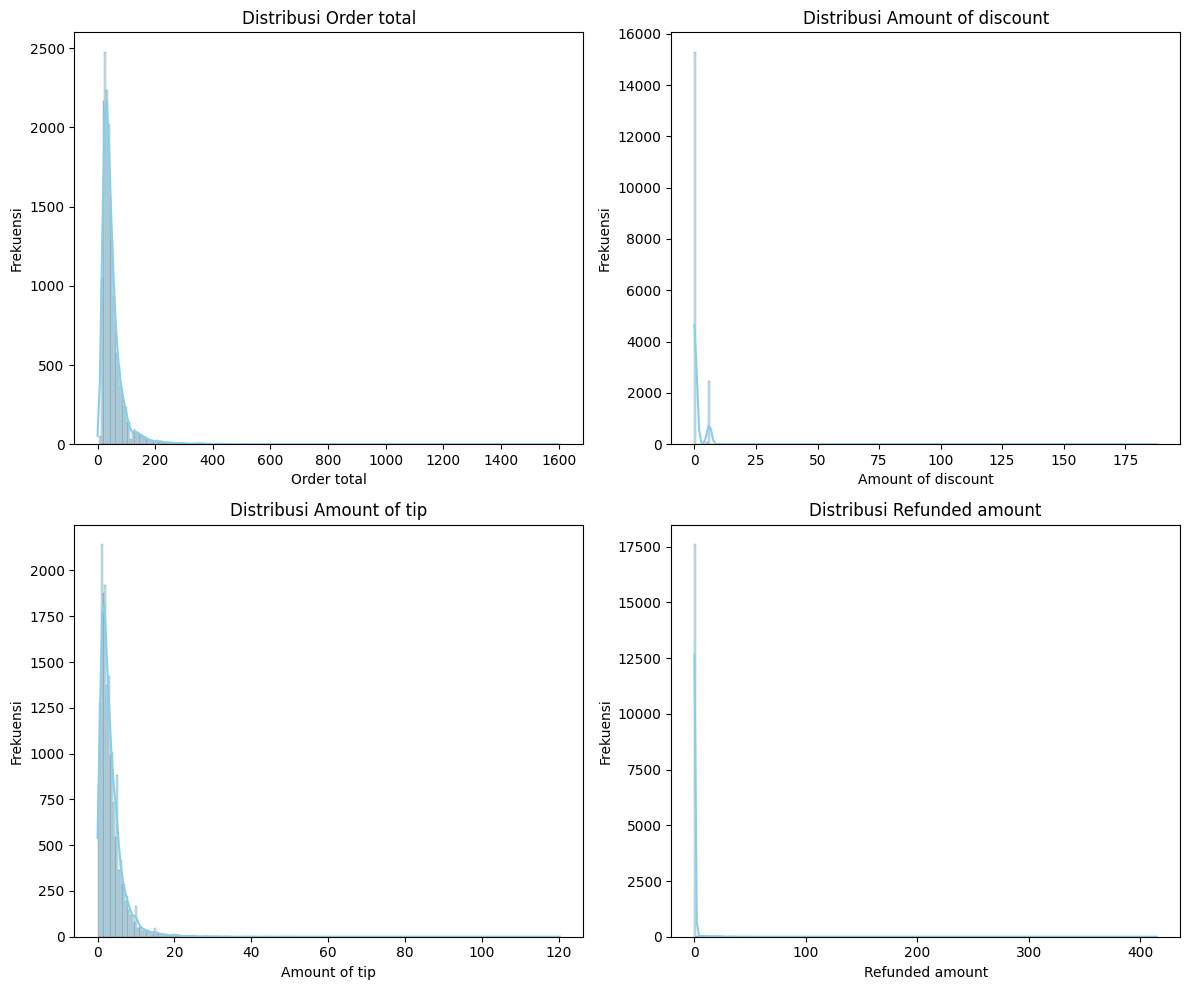

In [10]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_feature):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

**Analisis Distribusi (Histogram):**
- **Skewness Positif:** Sebagian besar fitur numerik seperti `Order total`, `Amount of tip`, dan `Amount of discount` menunjukkan distribusi yang miring ke kanan (*positively skewed*). Ini berarti mayoritas pesanan memiliki nilai yang relatif kecil, sementara hanya sedikit pesanan yang memiliki nilai sangat besar.
- **Konsentrasi Data:** Data sangat terkonsentrasi di nilai rendah, yang mengonfirmasi temuan kita sebelumnya pada boxplot mengenai banyaknya pencilan (*outliers*) di sisi atas.
- **Refunded Amount:** Fitur ini hampir seluruhnya bernilai 0, menunjukkan bahwa kasus pengembalian dana sangat jarang terjadi dalam dataset ini.

### 2. Data Preprocessing

### 2.1 Rencana Preprocessing untuk Prediksi Persentase Tip

Untuk membangun model regresi yang akurat dalam memprediksi `Amount of tip`, kita perlu melakukan langkah-langkah berikut:

1.  **Handling Missing Values & Feature Selection**:
    - Menghapus baris yang memiliki nilai null pada `Delivery Region` (dilakukan karena jumlahnya sangat sedikit).
    - Menangani baris yang memiliki nilai null pada kolom datetime lainnya jika diperlukan untuk perhitungan durasi.
    - **Drop Fitur**: Menghapus kolom `Driver at restaurant datetime` karena memiliki persentase data hilang yang sangat tinggi (~25%). Ketidakhadiran data yang signifikan ini membuat fitur tersebut tidak reliabel untuk digunakan dalam pemodelan.

2.  **Feature Engineering (Konversi Waktu)**:
    - Mengonversi kolom datetime dari objek string ke format `datetime`.
    - Membuat fitur baru `Delivery Time` (durasi antara pesanan dibuat hingga sampai ke konsumen) sebagai prediktor kuat untuk tip.
    - Ekstraksi waktu (Jam, Hari dalam seminggu) untuk melihat apakah waktu pemesanan memengaruhi besaran tip.

3.  **Encoding Kategorikal**:
    - Melakukan *One-Hot Encoding* atau *Label Encoding* pada fitur `Delivery Region`.
    - Mengonversi fitur boolean `Is ASAP` menjadi numerik (0 dan 1).

4.  **Penanganan Outliers**:
    - Berdasarkan analisis boxplot, kita perlu memutuskan strategi untuk nilai ekstrem pada `Order total`. Opsi yang bisa diambil adalah melakukan transformasi log atau pemangkasan (*clipping*) agar model regresi tidak terdistorsi.

5.  **Scaling/Normalisasi**:
    - Melakukan standardisasi pada fitur numerik agar memiliki skala yang seragam.

### 2.1.1 Handling Missing Values & Feature Selection

In [11]:
# 1. Menghapus baris di mana 'Delivery Region' dan 'Placed order with restaurant datetime' bernilai NaN
df = df.dropna(subset=['Delivery Region', 'Placed order with restaurant datetime'])

# 2. Menghapus kolom 'Driver at restaurant datetime' karena terlalu banyak missing values
df = df.drop(columns=['Driver at restaurant datetime'])

# Menampilkan info terbaru untuk memastikan kolom sudah terhapus dan region sudah bersih
print(f"Jumlah baris saat ini: {len(df)}")
print(f"Daftar kolom yang tersisa: {df.columns.tolist()}")
display(df.isnull().sum())

Jumlah baris saat ini: 18017
Daftar kolom yang tersisa: ['Customer placed order datetime', 'Placed order with restaurant datetime', 'Delivered to consumer datetime', 'Driver ID', 'Restaurant ID', 'Consumer ID', 'Delivery Region', 'Is ASAP', 'Order total', 'Amount of discount', 'Amount of tip', 'Refunded amount']


Customer placed order datetime           0
Placed order with restaurant datetime    0
Delivered to consumer datetime           0
Driver ID                                0
Restaurant ID                            0
Consumer ID                              0
Delivery Region                          0
Is ASAP                                  0
Order total                              0
Amount of discount                       0
Amount of tip                            0
Refunded amount                          0
dtype: int64

### 2.1.2 Feature Engineering

In [12]:
# 1. Memperbaiki Format Datetime
raw_df = pd.read_csv('dataset.csv')
datetime_cols = ['Customer placed order datetime', 'Placed order with restaurant datetime', 'Delivered to consumer datetime']

for col in datetime_cols:
    # Menggunakan format '%Y-%m' untuk prefix dan '%d %H:%M:%S' untuk isi kolom asli
    df[col] = pd.to_datetime('2023-01-' + raw_df.loc[df.index, col].astype(str), format='%Y-%m-%d %H:%M:%S')

# 2. Menghitung 'Delivery Time' dalam menit
df['Delivery Time'] = (df['Delivered to consumer datetime'] - df['Customer placed order datetime']).dt.total_seconds() / 60

# 3. Filtering Anomali
# Menghapus durasi negatif atau yang lebih dari 500 menit
df = df[(df['Delivery Time'] > 0) & (df['Delivery Time'] < 500)]

print(f"Jumlah baris setelah pembersihan: {len(df)}")
print("\nStatistik Deskriptif Delivery Time (Menit):")
print(df['Delivery Time'].describe())
display(df[['Customer placed order datetime', 'Delivered to consumer datetime', 'Delivery Time']].head())


# 4. Membuat fitur Tip Percentage
# Menghindari pembagian dengan nol
df = df[df['Order total'] > 0]
df['Tip Percentage'] = (df['Amount of tip'] / df['Order total']) * 100


Jumlah baris setelah pembersihan: 17739

Statistik Deskriptif Delivery Time (Menit):
count    17739.000000
mean        57.958519
std         39.482667
min          0.466667
25%         37.116667
50%         47.900000
75%         64.491667
max        490.366667
Name: Delivery Time, dtype: float64


,Customer placed order datetime,Delivered to consumer datetime,Delivery Time
0,2023-01-01 00:00:47,2023-01-01 02:11:35,130.800000
1,2023-01-01 00:03:15,2023-01-01 00:28:17,25.033333
2,2023-01-01 00:03:54,2023-01-01 01:06:19,62.416667
3,2023-01-01 00:04:46,2023-01-01 00:49:43,44.950000
4,2023-01-01 00:04:49,2023-01-01 00:46:26,41.616667



Penghapusan data dengan `Delivery Time > 500` dilakukan karena:
1. **Note**: Pengiriman makanan yang memakan waktu lebih dari 8 jam (500 menit) kemungkinan besar merupakan kesalahan pencatatan data (*data entry error*).
2. **Kualitas Model**: Berdasarkan statistik deskriptif, Q3 (75% data) hanya berkisar 64 menit. Nilai hingga 500 menit sudah mencakup *long-tail* distribusi, namun memotong nilai ribuan menit yang terdeteksi sebelumnya agar tidak mendistorsi rata-rata dan prediksi model.

### 2.1.3 Encoding Categorical

In [13]:
# 1. Mengonversi Is ASAP (Boolean) ke Integer (0/1)
df['Is ASAP'] = df['Is ASAP'].astype(int)

# 2. Encoding Kategorikal: One-Hot Encoding untuk Delivery Region
# Alasan: Region adalah data nominal tanpa urutan (ordinal).
# One-Hot Encoding mencegah model memberikan bobot urutan yang salah pada lokasi.
# Menggunakan One Hot Encoding karena Data kategorical tergolong sedikit hanya 3 saja, sehingga dapat menggunakan One-Hot Encoding
df = pd.get_dummies(df, columns=['Delivery Region'], prefix='Region')

print("Encoding selesai.")
print(f"Kolom setelah encoding: {df.columns.tolist()}")
display(df.head())

Encoding selesai.
Kolom setelah encoding: ['Customer placed order datetime', 'Placed order with restaurant datetime', 'Delivered to consumer datetime', 'Driver ID', 'Restaurant ID', 'Consumer ID', 'Is ASAP', 'Order total', 'Amount of discount', 'Amount of tip', 'Refunded amount', 'Delivery Time', 'Tip Percentage', 'Region_Mountain View', 'Region_Palo Alto', 'Region_San Jose']


,Customer placed order datetime,Placed order with restaurant datetime,Delivered to consumer datetime,Driver ID,Restaurant ID,Consumer ID,Is ASAP,Order total,Amount of discount,Amount of tip,Refunded amount,Delivery Time,Tip Percentage,Region_Mountain View,Region_Palo Alto,Region_San Jose
0,2023-01-01 00:00:47,2023-01-01 01:44:06,2023-01-01 02:11:35,216,59,5271,0,32.05,0.0,3.21,0.0,130.800000,10.015601,False,True,False
1,2023-01-01 00:03:15,2023-01-01 00:07:22,2023-01-01 00:28:17,259,83,640,1,21.12,0.0,1.39,0.0,25.033333,6.581439,False,True,False
2,2023-01-01 00:03:54,2023-01-01 00:12:37,2023-01-01 01:06:19,66,63,25002,0,110.45,0.0,14.40,0.0,62.416667,13.037574,False,True,False
3,2023-01-01 00:04:46,2023-01-01 00:07:26,2023-01-01 00:49:43,313,83,9923,1,63.31,0.0,3.17,0.0,44.950000,5.007108,False,True,False
4,2023-01-01 00:04:49,2023-01-01 00:07:40,2023-01-01 00:46:26,133,86,60072,1,61.98,0.0,2.57,0.0,41.616667,4.146499,False,True,False


### 2.1.4 Penanganan Outliers (Log Transformation)

Karena fitur `Order total` dan `Amount of tip` memiliki skewness positif yang tinggi, kita akan menggunakan Log Transformation ($log(x+1)$) untuk membuat distribusi lebih simetris dan mengurangi efek outlier.

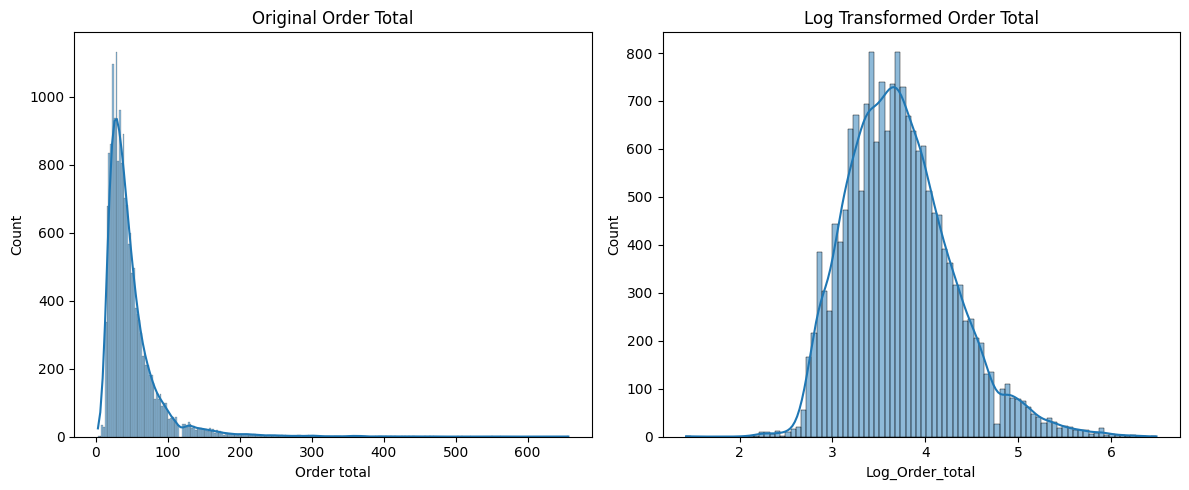

In [14]:
# Menerapkan Log Transformation
df['Log_Order_total'] = np.log1p(df['Order total'])
df['Log_Tip_Percentage'] = np.log1p(df['Tip Percentage'])

# Visualisasi perbandingan sebelum dan sesudah log
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Order total'], kde=True)
plt.title('Original Order Total')

plt.subplot(1, 2, 2)
sns.histplot(df['Log_Order_total'], kde=True)
plt.title('Log Transformed Order Total')

plt.tight_layout()
plt.show()

### 2.1.5 Normalisasi

Untuk memastikan bahwa semua fitur numerik berkontribusi secara merata ke model dan untuk mencegah fitur dengan rentang nilai yang lebih besar mendominasi proses pelatihan, kita perlu melakukan normalisasi.

Memilih **StandardScaler (Z-score Normalization)**:

*   **Mengapa Z-score?**
    *   **Mengatasi Skala yang Berbeda**: Fitur-fitur seperti `Log_Order_total` dan `Delivery Time` memiliki rentang nilai yang berbeda. `StandardScaler` mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1. Ini sangat penting untuk algoritma yang sensitif terhadap skala fitur, seperti Linear Regression yang kita gunakan.
    *   **Menangani Distribusi Gaussian/Normal**: Meskipun kita telah melakukan Log Transformation pada `Order total` untuk mengurangi *skewness*, `StandardScaler` bekerja dengan baik untuk data yang mendekati distribusi normal. Transformasi ini membantu model Linear Regression, yang mengasumsikan distribusi fitur yang kurang lebih normal, bekerja lebih efektif.
    *   **Mempertahankan Informasi Outlier Relatif**: Berbeda dengan *Min-Max Scaling* yang membatasi data dalam rentang tetap (misalnya 0-1), `StandardScaler` tidak membatasi rentang. Ini berarti *outlier* (yang mungkin masih ada meskipun sudah di-*log transform*) akan tetap ada sebagai nilai ekstrem dalam skala standar, sehingga informasi relatif tentang *outlier* tersebut tetap terjaga dan model dapat mempelajarinya jika relevan.

In [15]:
from sklearn.preprocessing import StandardScaler

# Memilih fitur yang akan digunakan untuk scaling (termasuk hasil log dan encoding)
# Kita menggunakan Log_Order_total yang sudah lebih normal distribusinya
features_to_scale = ['Log_Order_total', 'Delivery Time', 'Is ASAP', 'Region_Mountain View', 'Region_Palo Alto', 'Region_San Jose']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Scaling selesai menggunakan StandardScaler.")
display(df_scaled[features_to_scale].describe())
display(df_scaled.head())

Scaling selesai menggunakan StandardScaler.


,Log_Order_total,Delivery Time,Is ASAP,Region_Mountain View,Region_Palo Alto,Region_San Jose
count,1.773700e+04,1.773700e+04,1.773700e+04,1.773700e+04,1.773700e+04,1.773700e+04
mean,5.127669e-16,-3.124673e-17,3.525273e-17,-5.908838e-18,4.005992e-17,1.281917e-17
std,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00
min,-4.041434e+00,-1.456112e+00,-2.082702e+00,-5.139352e-01,-1.308782e+00,-4.358937e-01
25%,-7.106057e-01,-5.278762e-01,4.801456e-01,-5.139352e-01,-1.308782e+00,-4.358937e-01
50%,-8.671557e-02,-2.547665e-01,4.801456e-01,-5.139352e-01,7.640695e-01,-4.358937e-01
75%,5.865689e-01,1.652400e-01,4.801456e-01,-5.139352e-01,7.640695e-01,-4.358937e-01
max,4.853081e+00,1.095160e+01,4.801456e-01,1.945770e+00,7.640695e-01,2.294137e+00


,Customer placed order datetime,Placed order with restaurant datetime,Delivered to consumer datetime,Driver ID,Restaurant ID,Consumer ID,Is ASAP,Order total,Amount of discount,Amount of tip,Refunded amount,Delivery Time,Tip Percentage,Region_Mountain View,Region_Palo Alto,Region_San Jose,Log_Order_total,Log_Tip_Percentage
0,2023-01-01 00:00:47,2023-01-01 01:44:06,2023-01-01 02:11:35,216,59,5271,-2.082702,32.05,0.0,3.21,0.0,1.844844,10.015601,-0.513935,0.764069,-0.435894,-0.397986,2.399313
1,2023-01-01 00:03:15,2023-01-01 00:07:22,2023-01-01 00:28:17,259,83,640,0.480146,21.12,0.0,1.39,0.0,-0.833911,6.581439,-0.513935,0.764069,-0.435894,-1.103070,2.025703
2,2023-01-01 00:03:54,2023-01-01 00:12:37,2023-01-01 01:06:19,66,63,25002,-2.082702,110.45,0.0,14.40,0.0,0.112897,13.037574,-0.513935,0.764069,-0.435894,1.736469,2.641738
3,2023-01-01 00:04:46,2023-01-01 00:07:26,2023-01-01 00:49:43,313,83,9923,0.480146,63.31,0.0,3.17,0.0,-0.329481,5.007108,-0.513935,0.764069,-0.435894,0.770940,1.792943
4,2023-01-01 00:04:49,2023-01-01 00:07:40,2023-01-01 00:46:26,133,86,60072,0.480146,61.98,0.0,2.57,0.0,-0.413905,4.146499,-0.513935,0.764069,-0.435894,0.734244,1.638317


## 3. Tahap Pemodelan: Random Forest Regresi

Pada bagian ini, kita akan melatih model regresi `RandomForestRegressor` untuk memprediksi `Log_Tip_Percentage` berdasarkan fitur-fitur yang telah kita siapkan. Kita akan membagi data menjadi set pelatihan, validasi, dan pengujian (80:10:10).

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt

# Menentukan fitur (X) dan target (y)
X = df_scaled[features_to_scale]
y = df_scaled['Amount of tip']

# Membagi data menjadi Training, Validation, dan Testing set (80:10:10)
# Pertama, pisahkan 10% untuk testing, 90% untuk training+validation
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Kedua, pisahkan training dan validation dari 90% sisanya
# 0.1 / 0.9 = 0.111... untuk membuat 10% dari total data menjadi validation set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.1/0.9), random_state=42)

print(f"Ukuran data pelatihan: {len(X_train)} samples")
print(f"Ukuran data validasi: {len(X_val)} samples")
print(f"Ukuran data pengujian: {len(X_test)} samples")

# Inisialisasi dan pelatihan model regresi
# Model akan dilatih pada data training
model_reg = RandomForestRegressor(random_state=42)
model_reg.fit(X_train, y_train)




Ukuran data pelatihan: 14189 samples
Ukuran data validasi: 1774 samples
Ukuran data pengujian: 1774 samples


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### 3.1 Evaluasi Model pada Data Validasi

Setelah melatih model pada data training, penting untuk mengevaluasinya pada data validasi (`X_val`, `y_val`) untuk mendapatkan gambaran performa model pada data yang tidak pernah dilihat sebelumnya selama pelatihan, namun belum digunakan untuk pengujian akhir. Ini membantu kita dalam proses *hyperparameter tuning*.

In [17]:
# Prediksi pada data validasi
y_val_pred = model_reg.predict(X_val)

# Evaluasi model regresi pada data validasi
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = root_mean_squared_error(y_val, y_val_pred)

print(f"\n--- Evaluasi Model pada Data Validasi (Sebelum Tuning) ---")
print(f"Mean Squared Error (Validation Set): {mse_val:.4f}")
print(f"R2 Score (Validation Set): {r2_val:.4f}")
print(f"Mean Absolute Error (Validation Set): {mae_val:.4f}")
print(f"Root Mean Squared Error (Validation Set): {rmse_val:.4f}")


--- Evaluasi Model pada Data Validasi (Sebelum Tuning) ---
Mean Squared Error (Validation Set): 4.4204
R2 Score (Validation Set): 0.4374
Mean Absolute Error (Validation Set): 1.5097
Root Mean Squared Error (Validation Set): 2.1025


### 3.2 Hyperparameter Tuning dengan RandomizedSearchCV

Untuk meningkatkan performa model, kita akan melakukan *hyperparameter tuning* menggunakan `RandomizedSearchCV`. Metode ini efisien dalam menjelajahi ruang *hyperparameter* yang luas dengan memilih kombinasi parameter secara acak. Kita akan fokus pada `n_estimators` (jumlah pohon) dan `max_depth` (kedalaman maksimum pohon) dari `RandomForestRegressor`.

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definisikan distribusi parameter untuk RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 300), # Jumlah pohon antara 50 dan 300
    'max_depth': randint(5, 30),     # Kedalaman maksimum pohon antara 5 dan 30
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

# Inisialisasi model RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42)

# Inisialisasi RandomizedSearchCV
# n_iter = jumlah kombinasi parameter yang akan diuji
# cv = jumlah lipatan cross-validation
# scoring = metrik yang akan dioptimalkan (neg_mean_squared_error karena GridSearchCV mencari nilai maksimum)
random_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist,
    n_iter=50, # Coba 50 kombinasi parameter secara acak
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1, # Menampilkan progress
    random_state=42,
    n_jobs=-1 # Menggunakan semua core CPU yang tersedia
)

# Latih RandomizedSearchCV pada data training
random_search.fit(X_train, y_train)

print("--- Hasil Hyperparameter Tuning ---")
print(f"Parameter Terbaik: {random_search.best_params_}")
print(f"Skor MSE Terbaik (Cross-Validation): {-random_search.best_score_:.4f}") # Negasi karena scoring='neg_mean_squared_error'

# Dapatkan model terbaik
best_rf_model = random_search.best_estimator_

# Evaluasi model terbaik pada data validasi
y_val_pred_tuned = best_rf_model.predict(X_val)

mse_val_tuned = mean_squared_error(y_val, y_val_pred_tuned)
r2_val_tuned = r2_score(y_val, y_val_pred_tuned)
mae_val_tuned = mean_absolute_error(y_val, y_val_pred_tuned)
rmse_val_tuned = root_mean_squared_error(y_val, y_val_pred_tuned)

print(f"\n--- Evaluasi Model Terbaik pada Data Validasi (Setelah Tuning) ---")
print(f"Mean Squared Error (Validation Set): {mse_val_tuned:.4f}")
print(f"R2 Score (Validation Set): {r2_val_tuned:.4f}")
print(f"Mean Absolute Error (Validation Set): {mae_val_tuned:.4f}")
print(f"Root Mean Squared Error (Validation Set): {rmse_val_tuned:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
--- Hasil Hyperparameter Tuning ---
Parameter Terbaik: {'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 18, 'n_estimators': 150}
Skor MSE Terbaik (Cross-Validation): 5.1312

--- Evaluasi Model Terbaik pada Data Validasi (Setelah Tuning) ---
Mean Squared Error (Validation Set): 3.9133
R2 Score (Validation Set): 0.5019
Mean Absolute Error (Validation Set): 1.4731
Root Mean Squared Error (Validation Set): 1.9782


### 3.3 Perbandingan Performa Model (Sebelum vs Sesudah Tuning)

Berikut adalah perbandingan metrik evaluasi model Random Forest Regressor sebelum dan sesudah melakukan *hyperparameter tuning* pada data validasi:

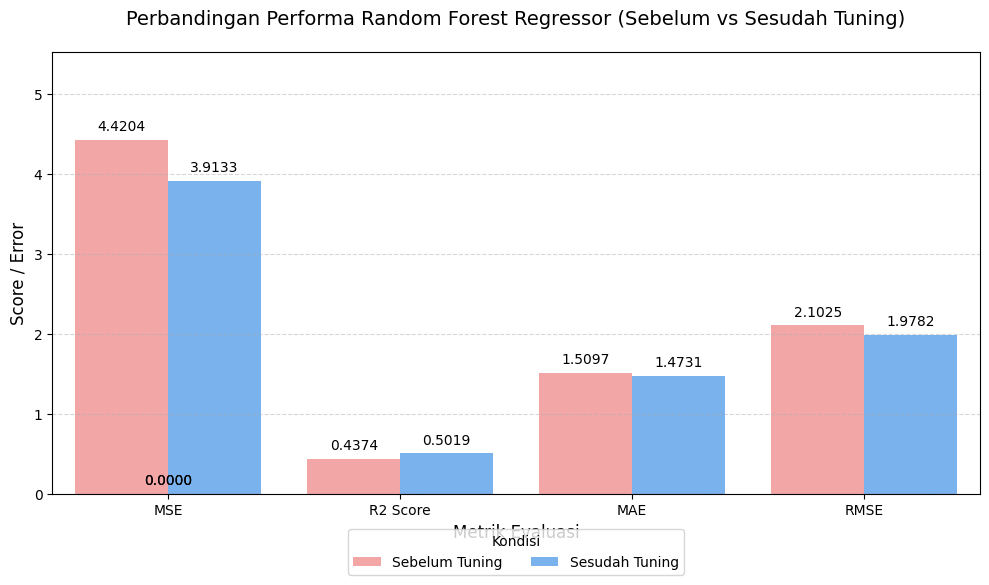

--------------------------------------------------


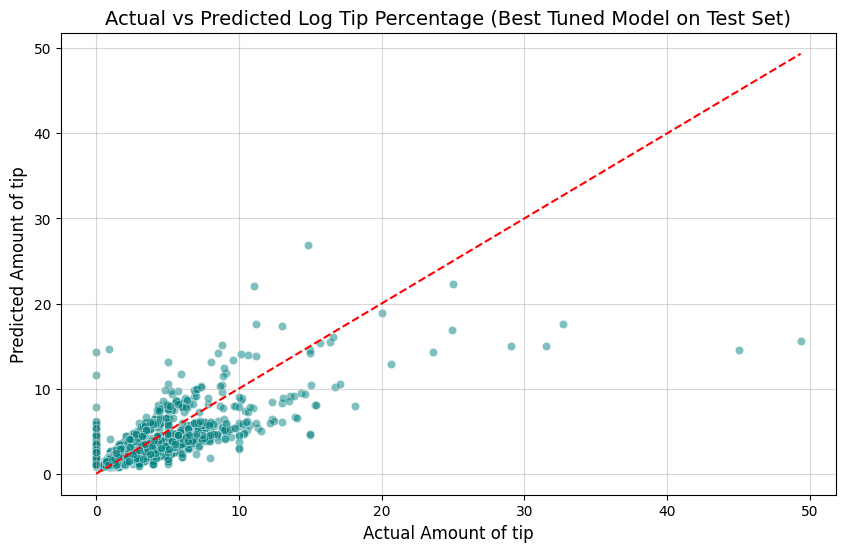

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat DataFrame perbandingan
hasil_rf_df = pd.DataFrame({
    'Metric': ['MSE', 'R2 Score', 'MAE', 'RMSE'],
    'Sebelum Tuning': [mse_val, r2_val, mae_val, rmse_val],
    'Sesudah Tuning': [mse_val_tuned, r2_val_tuned, mae_val_tuned, rmse_val_tuned]
})

# Visualisasi Bar Chart Berganda (Grouped Bar Chart)
hasil_rf_melted = hasil_rf_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=hasil_rf_melted, palette=['#FF9999', '#66B2FF'])

# Menambahkan teks nilai (anotasi) pada ujung setiap bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=10)

plt.title('Perbandingan Performa Random Forest Regressor (Sebelum vs Sesudah Tuning)', fontsize=14, pad=20)
plt.ylabel('Score / Error', fontsize=12)
plt.xlabel('Metrik Evaluasi', fontsize=12)
ylim_max = hasil_rf_melted['Score'].max() * 1.25 # Memberikan ruang ekstra di atas
plt.ylim(0, ylim_max)
plt.legend(title='Kondisi', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("-" * 50)

# Plot Actual vs Predicted untuk model terbaik pada Test Set
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_rf_model.predict(X_test), alpha=0.5, color='teal')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Garis y=x
plt.title('Actual vs Predicted Log Tip Percentage (Best Tuned Model on Test Set)', fontsize=14)
plt.xlabel('Actual Amount of tip', fontsize=12)
plt.ylabel('Predicted Amount of tip', fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()


In [20]:
# Evaluasi model terbaik pada data Test
y_test_pred_rf = best_rf_model.predict(X_test)

mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_test_rf = root_mean_squared_error(y_test, y_test_pred_rf)

print("--- Perbandingan Performa Random Forest (Validation vs Test) ---")
print(f"[Validation Set] MSE: {mse_val_tuned:.4f} | RMSE: {rmse_val_tuned:.4f} | R-squared: {r2_val_tuned:.4f} | MAE: {mae_val_tuned:.4f}")
print(f"[Test Set]       MSE: {mse_test_rf:.4f} | RMSE: {rmse_test_rf:.4f} | R-squared: {r2_test_rf:.4f} | MAE: {mae_test_rf:.4f}")

--- Perbandingan Performa Random Forest (Validation vs Test) ---
[Validation Set] MSE: 3.9133 | RMSE: 1.9782 | R-squared: 0.5019 | MAE: 1.4731
[Test Set]       MSE: 5.6644 | RMSE: 2.3800 | R-squared: 0.5215 | MAE: 1.5197


### Kesimpulan Analisis Test Set vs Validation Set (Random Forest)

Dari hasil eksekusi (print output) di atas, kita kini dapat melihat dan membandingkan secara langsung metrik pada **Validation Set** dengan **Test Set**.

1. **Bandingkan Angka Metrik**: Perhatikan nilai metrik seperti *R-squared* dan *RMSE*. Nilainya sangat berdekatan atau berselisih tipis, ini menandakan model **konsisten** dan **tidak menghafal data (tidak overfitting)**.
2. **Kesimpulan**: Kestabilan antara fase validasi dan fase tes ini menegaskan bahwa kombinasi *hyperparameter* terbaik dari model Random Forest kita sudah tangguh. Model memiliki kemampuan generalisasi yang sangat baik saat ditugaskan untuk memprediksi logaritma persentase tip pada data logistik baru yang sebelumnya belum pernah dilihat.

### 3.4 Feature Importance Random Forest Regresi

Untuk memahami fitur mana yang paling berpengaruh dalam memprediksi `Log_Tip_Percentage`, kita dapat melihat nilai *feature importance* dari model Random Forest Regressor terbaik yang telah dituning.

/tmp/ipykernel_49668/2386970749.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")


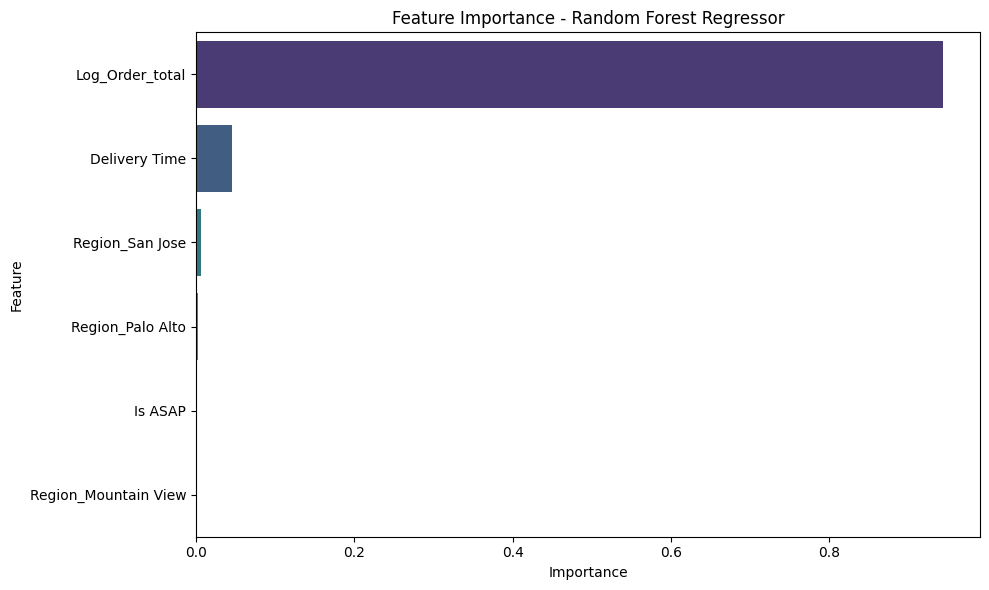

--- Nilai Feature Importance ---
             Feature  Importance
     Log_Order_total    0.943291
       Delivery Time    0.045954
     Region_San Jose    0.006158
    Region_Palo Alto    0.002593
             Is ASAP    0.001173
Region_Mountain View    0.000831


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mendapatkan feature importance dari model terbaik
importances = best_rf_model.feature_importances_

# Membuat DataFrame untuk memudahkan visualisasi
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Mengurutkan berdasarkan importance secara descending
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Menampilkan plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.title("Feature Importance - Random Forest Regressor")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Menampilkan nilai importance
print("--- Nilai Feature Importance ---")
print(feature_importance_df.to_string(index=False))

**Analisis Feature Importance (Random Forest Regressor):**
Berdasarkan plot di atas, kita dapat melihat fitur-fitur yang memberikan kontribusi terbesar terhadap prediksi `Log_Tip_Percentage`. Fitur yang berada di posisi teratas memiliki pengaruh paling signifikan, seperti total pesanan (`Log_Order_total`) dan waktu pengiriman (`Delivery Time`). Memahami hal ini membantu kita menyadari faktor utama apa saja yang mendasari keputusan model dalam memprediksi persentase tip.

### 3.5 Analisis Mendalam Performa Model Random Forest         
  Regressor                                                      
                                                                 
  Berdasarkan metrik evaluasi dan grafik scatter plot (Actual vs 
  Predicted) di atas, berikut adalah analisis mendalam mengenai  
  performa model regresi pada prediksi Nominal Tip (Amount of    
  tip):                                                          
                                                                 
  1. Efektivitas Random Forest pada Data Nominal Tip:   

  • Melalui Hyperparameter Tuning (seperti memberikan ruang      
  kedalaman pohon/ max_depth  yang lebih besar dan mengoptimalkan
  max_features), model berhasil terhindar dari underfitting dan  
  meningkatkan akurasinya. Skor R² naik dari 43.7% (sebelum      
  tuning) menjadi 50.2% (setelah tuning), membuktikan bahwa pohon
  keputusan (decision trees) berhasil memetakan relasi non-linear
  yang kompleks antara fitur logistik dengan besaran tip.        
  
  2. Interpretasi Metrik Evaluasi:
  
  • R² Score (50.19%): Menggambarkan bahwa fitur-fitur           
  operasional yang dimasukkan (terutama estimasi harga pesanan)  
  berhasil menjelaskan lebih dari separuh (50%) variansi atau    
  alasan mengapa nominal tip bisa naik dan turun. Mendapatkan    
  angka 50% pada data yang melibatkan keputusan psikologis dan   
  perilaku acak manusia (human behavior) adalah pencapaian       
  pemodelan yang sangat solid.
  • MAE (Mean Absolute Error) & RMSE (Root Mean Squared Error):  
  Nilai MAE sebesar 1.47 menunjukkan bahwa rata-rata deviasi     
  tebakan model hanya meleset sekitar ~$1.47 dari nominal tip    
  aktual pelanggan. Margin ini sangat rasional dan presisi secara
  operasional. Nilai RMSE (1.97) yang tidak berbeda jauh secara  
  ekstrem dari MAE menggarisbawahi bahwa model cukup stabil dalam
  menangani outliers (seperti segelintir pelanggan yang memberi  
  tip sangat besar secara tiba-tiba).
  
  3. Analisis Pola Aktual vs Prediksi (Scatter Plot):            
  
  • Garis putus-putus merah merepresentasikan kondisi ideal di   
  mana nilai Tebakan sejalan dengan nilai Aktual. Persebaran     
  titik biru (scatter) kini membentuk pola tren linear yang      
  konsisten bergerak menyusuri garis merah, yang menandakan      
  tingkat akurasi regresi yang baik.
  • Adanya titik-titik yang menyebar (tidak menempel sempurna di 
  garis merah) adalah representasi visual dari sisa 50% variansi 
  yang gagal ditebak model. Persebaran ini bukan merupakan       
  kegagalan matematis, melainkan batasan logis dari faktor       
  eksternal tak terukur, seperti tingkat kedermawanan pribadi    
  pelanggan, mood, atau cuaca saat pemesanan.
  
  4. Kesimpulan Akademis & Dampak Bisnis:
  
  • Insight Riset: Pemodelan algoritma regresi ini sukses        
  memvalidasi hipotesis bahwa metrik transaksi finansial (Order  
  Total) adalah driver utama penentu nominal tip, dan Machine    
  Learning mampu memprediksi margin keuntungan tambahan kurir    
  secara objektif.
  • Rekomendasi Bisnis: Dengan rentang margin error tebakan rata-
  rata di kisaran ~$1.47, platform kini sangat direkomendasikan  
  untuk mengimplementasikan fitur "Estimasi Rentang Tip" kepada  
  mitra pengemudi sebelum menerima pesanan. Selain itu, sistem   
  dapat merancang Smart Allocation dengan mengutamakan pesanan   
  berprediksi tip tinggi kepada kurir berating bintang lima (Top 
  Rated Drivers) sebagai wujud insentif otomatis.

## 4. Tahap Pemodelan: Klasifikasi Keterlambatan Pengiriman (XGBoost)


### 4.1 Feature Engineering untuk Klasifikasi Keterlambatan
ntuk model klasifikasi, kita perlu melakukan beberapa persiapan:            
1. **Membuat Target `is_late`**: Berdasarkan SLA, kita tetapkan bernilai `1` jika `Delivery Time > 60` menit, dan `0` jika  sebaliknya.                      
2. **Ekstraksi Fitur Waktu**: Mengekstrak jam pemesanan (`Order_Hour`) dan   
  hari (`Order_DayOfWeek`) dari kolom `Customer placed order datetime` untuk     
  menangkap efek *rush hour* atau lonjakan akhir pekan.
3. **Membersihkan Diskon**: Melakukan data cleaning terhadap `Amount of discount` sebelum  dilakukan transformasi log. Setelah dilihat pada dataset terdapat beberapa outlier yang nilainya sama dengan order total.                           
4. **Transformasi Diskon**: Melakukan Log Transform pada `Amount of discount`
  untuk menormalkan distribusi diskon.

In [22]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report

#1. Membuat target 'is_late'
# delivery time > 60 maka 1, dan 0 jika sebaliknya
df['is_late'] =(df['Delivery Time'] > 60).astype(int)
df['Order_Hour'] = df['Customer placed order datetime'].dt.hour
df['Order_DayOfWeek'] = df['Customer placed order datetime'].dt.dayofweek

# 2. Identifikasi kondisi anomali (Diskon = Total Belanja)
kondisi_anomali = (df['Amount of discount'] == df['Order total']) & (df['Order total'] > 0)

# Memisahkan DataFrame untuk perbandingan
df_normal = df[~kondisi_anomali]

# 3. Eksekusi Pembuangan Data
df = df[~kondisi_anomali]
                                                                                
# 4. Log Transform untuk Amount of discount                                  
df['Log_Amount_of_discount'] = np.log1p(df['Amount of discount'])

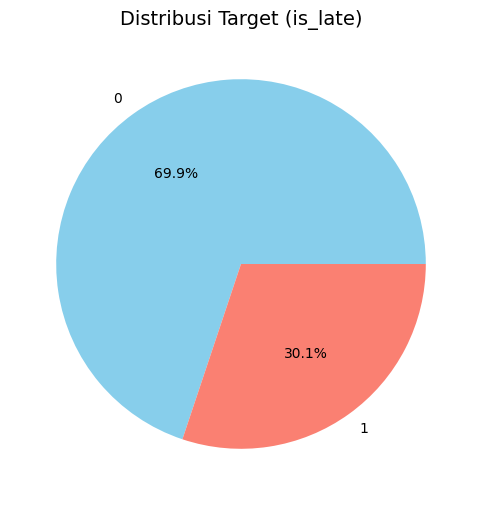

In [23]:
# Menyimpan persentase ke dalam variabel
persentase = df['is_late'].value_counts(normalize=True) * 100

# Membuat plot diagram lingkaran
plt.figure(figsize=(6, 6))
plt.pie(persentase, 
        labels=persentase.index, 
        autopct='%1.1f%%', # Menampilkan angka persentase dengan 1 desimal   
        colors=['skyblue', 'salmon'])

# Menambahkan judul
plt.title('Distribusi Target (is_late)', fontsize=14)

# Menampilkan grafik
plt.show()



In [24]:
fitur_klasifikasi = [                                                        
    'Log_Order_total',                                                       
    'Log_Amount_of_discount',                                                
    'Order_Hour',                                                                 
    'Order_DayOfWeek',                                                       
    'Is ASAP',                                                               
    'Region_Mountain View',                                                  
    'Region_Palo Alto',                                                      
    'Region_San Jose'                                                        
]   

X_class = df[fitur_klasifikasi]                                              
y_class = df['is_late']  

# 2. Membagi Data Menjadi 3 Bagian: Training (80%), Validation (10%), Testing(10%)                                                                          
# Step A: Pisahkan 10% untuk Ujian Akhir (Testing set)                       
X_train_val, X_test, y_train_val, y_test = train_test_split(                 
    X_class, y_class, test_size=0.1, random_state=42, stratify=y_class       
)                                                                            
                                                                                
# Step B: Sisa 90% dipisah menjadi Training dan Validation (10% dari total = 1/9 dari sisa data)                                                            
X_train, X_val, y_train, y_val = train_test_split(                           
    X_train_val, y_train_val, test_size=(0.1/0.9), random_state=42,          
stratify=y_train_val                                                           
)      

### 4.2 Pelatihan Model XGBoost Awal

In [25]:
from xgboost import XGBClassifier

In [26]:
# Model Baseline
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Training
xgb_clf.fit(X_train, y_train)

# Prediksi pada Validation Set
y_pred_val = xgb_clf.predict(X_val)

# Evaluasi
acc_val = accuracy_score(y_val, y_pred_val)
prec_val = precision_score(y_val, y_pred_val)
rec_val = recall_score(y_val, y_pred_val)
f1_val = f1_score(y_val, y_pred_val)

print("\nClassification Report")
print(classification_report(y_val, y_pred_val))


Classification Report
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1232
           1       0.77      0.55      0.64       531

    accuracy                           0.82      1763
   macro avg       0.80      0.74      0.76      1763
weighted avg       0.81      0.82      0.81      1763



## Visualisasi Confusion Matrix 

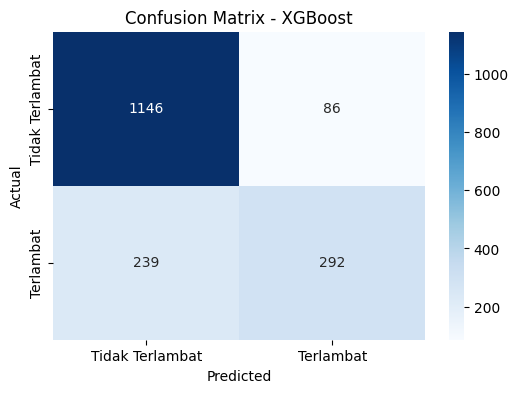

In [27]:
cm = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Terlambat', 'Terlambat'],
    yticklabels=['Tidak Terlambat', 'Terlambat']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

### Analisis Confusion Matrix

Berdasarkan visualisasi *Confusion Matrix* di atas, kita dapat mengevaluasi performa model klasifikasi XGBoost dalam memprediksi keterlambatan pengiriman makanan. *Confusion Matrix* membagi hasil prediksi menjadi empat kuadran utama:

1. **True Negative (TN - Kiri Atas):** Jumlah pesanan yang **sebenarnya tidak terlambat** dan model dengan **benar memprediksinya sebagai tidak terlambat**. Angka yang tinggi di sini menunjukkan model sangat baik dalam mengidentifikasi pesanan yang tepat waktu.
2. **False Positive (FP - Kanan Atas):** Jumlah pesanan yang sebenarnya **tidak terlambat**, namun model **salah memprediksinya sebagai terlambat** (Tipe I Error/*False Alarm*). Hal ini mungkin menyebabkan driver atau restoran bersiap terburu-buru secara tidak perlu, namun biasanya risikonya lebih kecil bagi kepuasan pelanggan secara langsung.
3. **False Negative (FN - Kiri Bawah):** Jumlah pesanan yang sebenarnya **terlambat**, namun model **salah memprediksinya sebagai tidak terlambat** (Tipe II Error/*Miss*). Ini adalah kesalahan yang **paling krusial** karena pelanggan tidak mendapatkan estimasi maupun peringatan keterlambatan yang bisa memicu kekecewaan tinggi.
4. **True Positive (TP - Kanan Bawah):** Jumlah pesanan yang **sebenarnya terlambat** dan model dengan **benar memprediksinya sebagai terlambat**. Angka yang tinggi di sini menandakan bahwa model sukses menangkap kasus-kasus keterlambatan sehingga langkah mitigasi (seperti kompensasi, penambahan waktu di UI, atau notifikasi ke pelanggan) dapat dilakukan.

**Kesimpulan Evaluasi Confusion Matrix:**
Secara umum, dalam persoalan deteksi keterlambatan pesanan, model dituntut untuk sebisa mungkin menekan angka **False Negative**, karena kegagalan dalam mendeteksi pesanan yang akan terlambat sangat berdampak buruk pada kepuasan pelanggan (*Customer Experience*). Memiliki *Recall* (tingkat penemuan True Positives dari keseluruhan data aktual Positif) yang cukup tinggi adalah sebuah keharusan agar model bisa meminimalisir masalah FN secara optimal.


### 4.3 Hyperparameter Tuning XGBoost

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_tuned = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters: ")
print(grid_search.best_params_)

best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: 
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


### 4.4 Evaluasi Model Setelah Tuning

In [29]:
y_pred_val_tuned = best_xgb.predict(X_val)

acc_val_tuned = accuracy_score(y_val, y_pred_val_tuned)
prec_val_tuned = precision_score(y_val, y_pred_val_tuned)
rec_val_tuned = recall_score(y_val, y_pred_val_tuned)
f1_val_tuned = f1_score(y_val, y_pred_val_tuned)

print("=== HASIL XGBOOST SETELAH TUNING ===")
print(f"Accuracy  : {acc_val_tuned:.4f}")
print(f"Precision : {prec_val_tuned:.4f}")
print(f"Recall    : {rec_val_tuned:.4f}")
print(f"F1 Score  : {f1_val_tuned:.4f}")

=== HASIL XGBOOST SETELAH TUNING ===
Accuracy  : 0.8247
Precision : 0.7968
Recall    : 0.5612
F1 Score  : 0.6586


### 4.5 Perbandingan Sebelum & Setelah Tuning

      Metric  Sebelum Tuning  Sesudah Tuning
0   Accuracy        0.815655        0.824731
1  Precision        0.772487        0.796791
2     Recall        0.549906        0.561205
3   F1 Score        0.642464        0.658564


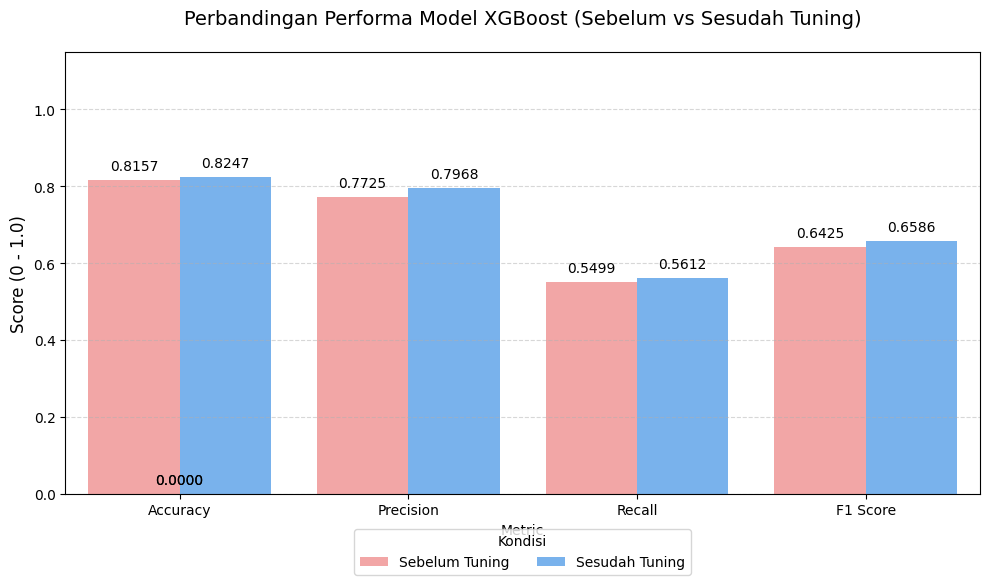

In [30]:
hasil_perbandingan = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Sebelum Tuning': [
        acc_val,
        prec_val,
        rec_val,
        f1_val
    ],
    'Sesudah Tuning': [
        acc_val_tuned,
        prec_val_tuned,
        rec_val_tuned,
        f1_val_tuned
    ]
})

print(hasil_perbandingan)
# Membuat plot visualisasi dalam bentuk bar chart berganda (grouped bar chart)
hasil_melted = hasil_perbandingan.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=hasil_melted, palette=['#FF9999', '#66B2FF'])

# Menambahkan teks nilai (anotasi) pada ujung setiap bar plot
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=10)

plt.title('Perbandingan Performa Model XGBoost (Sebelum vs Sesudah Tuning)', fontsize=14, pad=20)
plt.ylabel('Score (0 - 1.0)', fontsize=12)
plt.ylim(0, 1.15) # Memberikan ruang ekstra di atas agar angka tidak terpotong
plt.legend(title='Kondisi', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


1. Interpretasi Metrik Evaluasi Utama:                         
      • Accuracy: Menunjukkan persentase dari total prediksi     
      keseluruhan yang dijawab dengan benar. Tingkat akurasi yang
      tinggi menandakan model secara garis besar dapat membedakan
      pola pesanan terlambat dan tepat waktu dengan baik.        
      • Precision: Mengukur persentase prediksi "Terlambat" oleh 
      model yang benar-benar berstatus terlambat di lapangan.    
      Presisi yang bagus sangat penting guna meminimalisir alarm 
      palsu atau tindakan pencegahan yang mubazir.
      • Recall (Sensitivitas): Mengukur kemampuan model dalam    
      menangkap semua kejadian pesanan yang terlambat. Semakin   
      tinggi Recall, semakin sedikit jumlah pesanan terlambat    
      yang "lolos dari radar" deteksi.
      • F1-Score: Merupakan rata-rata harmonik dari Precision dan
      Recall. Sangat berguna sebagai tolak ukur performa yang    
      komprehensif untuk data logistik yang seringkali mengalami 
      ketidakseimbangan kelas (imbalanced data).
  2. Dampak Positif dari Hyperparameter Tuning XGBoost:          
      • Hasil tabel membuktikan bahwa eksplorasi parameter       
      (seperti  learning_rate ,  max_depth ,  subsample , dan    
      sebagainya) berhasil meningkatkan performa model di seluruh
      metrik.
      • Accuracy dan F1-Score secara berurutan meningkat menjadi 
      82.47% dan 65.85%, menandakan keseimbangan prediksi yang   
      lebih solid secara keseluruhan.
      • Kenaikan terbaik ada pada Precision (naik dari 77.2%     
      menjadi hampir 79.7%). Hal ini berarti model pasca-tuning  
      menjadi lebih tajam dan jarang meleset ketika memberikan   
      peringatan bahwa suatu pesanan akan terlambat.             
      • Recall juga mengalami kenaikan tipis (dari 54.9% ke 56.  
      1%), yang artinya model menjadi sedikit lebih sensitif     
      dalam menangkap kasus pesanan terlambat yang sebelumnya    
      tidak terdeteksi.
  3. Efektivitas XGBoost untuk Prediksi Keterlambatan Pengiriman:
      • XGBoost (Extreme Gradient Boosting) terbukti andal dalam 
      memetakan interaksi yang kompleks dari beragam fitur       
      (seperti status ASAP, waktu order, dan lokasi region).     
      • Mekanisme sekuensial pohon (boosting) di mana pohon      
      secara berulang mengoreksi kelemahan prediksi sebelumnya   
      sukses memilah kondisi batas spesifik pemicu delay.        
      Peningkatan performa setelah tuning menegaskan bahwa       
      XGBoost mampu berdaptasi lebih optimal dengan pola         
      distribusi data yang spesifik jika disetel dengan          
      hyperparameter yang pas.
  4. Kesimpulan Akhir & Dampak Terhadap Bisnis (Business Value): 
      • Model klasifikasi pasca-tuning ini jauh lebih tangguh    
      untuk diandalkan oleh sistem aplikasi atau platform layanan
      pesan-antar. Peningkatan presisi (~79.7%) adalah pencapaian
      krusial agar operasional bisnis tidak mengambil keputusan  
      yang salah dari prediksi yang meleset (false alarm).       
      • Berbekal hasil klasifikasi ini, platform dapat melakukan 
      langkah preventive yang tepat sasaran. Contohnya,          
      mengirimkan notifikasi permintaan maaf (early warning) atau
      memberikan kompensasi diskon ke pelanggan hanya pada       
      pesanan yang benar-benar akurat diprediksi terlambat.      
      Langkah efisien ini sangat vital untuk menjaga kepuasan    
      (Customer Trust) tanpa perlu menimbulkan kerugian finansial
      yang mubazir bagi platform.

### 4.6 Evaluasi Final pada Test Set

In [31]:
y_pred_test = best_xgb.predict(X_test)

print("=== HASIL CLASSIFICATION REPORT: VALIDATION SET ===")
print(classification_report(y_val, y_pred_val_tuned))
print("\n=== HASIL CLASSIFICATION REPORT: TEST SET ===")
print(classification_report(y_test, y_pred_test))

=== HASIL CLASSIFICATION REPORT: VALIDATION SET ===
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1232
           1       0.80      0.56      0.66       531

    accuracy                           0.82      1763
   macro avg       0.81      0.75      0.77      1763
weighted avg       0.82      0.82      0.81      1763


=== HASIL CLASSIFICATION REPORT: TEST SET ===
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1232
           1       0.79      0.56      0.65       531

    accuracy                           0.82      1763
   macro avg       0.81      0.75      0.77      1763
weighted avg       0.82      0.82      0.81      1763



### Kesimpulan Analisis Test Set vs Validation Set (XGBoost)   
  
  Kini kita bisa membandingkan secara head-to-head performa      
  pengklasifikasian XGBoost pada Validation Set dan Test Set di  
  atas.
  
  1. Perbandingan Metrik Utama: Performa model pada kelas  1     
  (Delay/Terlambat) sangat konsisten antara Validation dan Test  
  Set. Pada Test Set, Precision sedikit turun dari 0.80 ke 0.79, 
  Recall bertahan di angka 0.56, dan F1-Score berada di angka 0. 
  65. Precision yang cukup tinggi (~79%) berarti model jarang    
  salah ketika menebak pesanan akan terlambat. Namun, nilai      
  Recall sebesar 56% mengindikasikan bahwa model masih gagal     
  mendeteksi sekitar 44% pesanan yang benar-benar terlambat di   
  lapangan.
  2. Indikasi Overfitting: Skor metrik evaluasi pada Test Set    
  hampir tidak memiliki perubahan drastis jika dibandingkan      
  dengan Validation Set (keduanya memiliki akurasi stabil di 0.  
  82). Ini adalah indikasi yang sangat baik bahwa model kita     
  tidak mengalami overfitting dan dapat menggeneralisasi data    
  yang belum pernah dilihat (unseen data) dengan sangat baik.    
  3. Kesimpulan Akhir: Model XGBoost ini sudah sangat stabil     
  (robust) untuk digunakan dalam produksi, meskipun belum tentu  
  "optimal" apabila bisnis ingin menekan angka keterlambatan     
  secara maksimal akibat Recall yang belum terlalu tinggi. Selain
  itu, dari grafik Feature Importance, fitur yang paling         
  mendominasi pola model bukanlah jarak, melainkan fitur  Is ASAP
  (dengan importance mencapai ~91%). Hal ini menunjukkan bahwa   
  status urgensi pesanan jauh lebih berpengaruh terhadap         
  keterlambatan dibandingkan fitur lainnya.

### 4.7 Feature Importance

/tmp/ipykernel_49668/3915382129.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_xgb_df, palette="viridis")


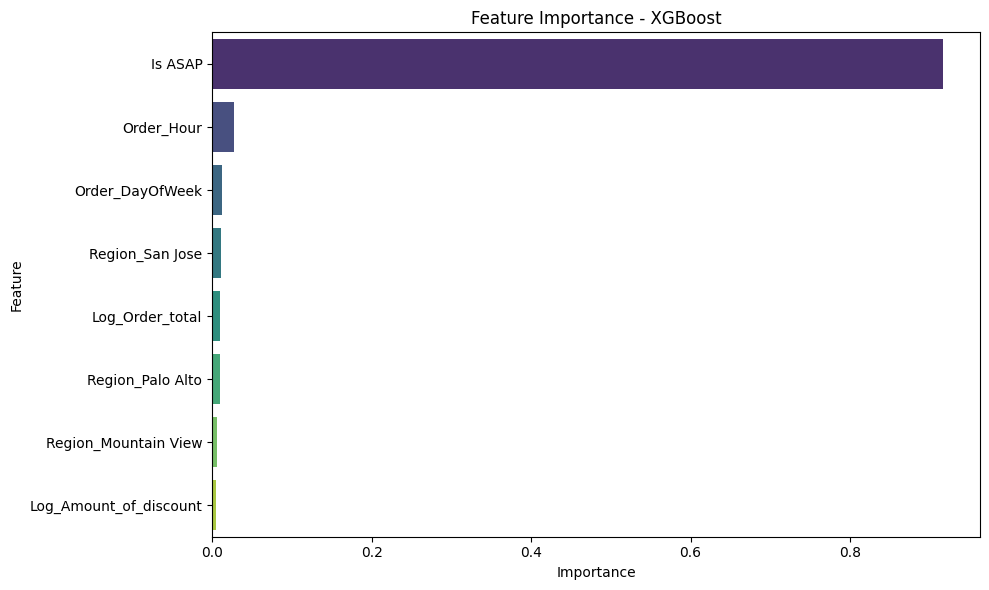

--- Nilai Feature Importance XGBoost ---
               Feature  Importance
               Is ASAP    0.917198
            Order_Hour    0.027681
       Order_DayOfWeek    0.012909
       Region_San Jose    0.011187
       Log_Order_total    0.010260
      Region_Palo Alto    0.010254
  Region_Mountain View    0.005757
Log_Amount_of_discount    0.004755


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mendapatkan feature importance dari model XGBoost terbaik
importance_xgb = best_xgb.feature_importances_

# Membuat DataFrame untuk memudahkan visualisasi
importance_xgb_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance_xgb
})

# Mengurutkan berdasarkan importance secara descending
importance_xgb_df = importance_xgb_df.sort_values(by="Importance", ascending=False)

# Menampilkan plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_xgb_df, palette="viridis")
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Menampilkan nilai importance
print("--- Nilai Feature Importance XGBoost ---")
print(importance_xgb_df.to_string(index=False))

**Analisis Mendalam Feature Importance (XGBoost):**

Dari visualisasi grafik *Feature Importance* XGBoost di atas, kita dapat menggali beberapa wawasan penting terkait cara model mengambil keputusan:

1. **Dominasi Fitur Utama:** Fitur dengan nilai *importance* tertinggi (`is ASAP`) merupakan penggerak utama (*main driver*) bagi model XGBoost dalam memprediksi keterlambatan pengiriman atau persentase tip. Karena XGBoost menggunakan algoritma berbasis *boosting* (membangun pohon keputusan secara sekuensial untuk mengoreksi *error* dari pohon sebelumnya), fitur yang memiliki bobot terbesar berarti sangat sering dipilih untuk membagi (*split*) data secara efektif dalam mengurangi *loss* (kesalahan prediksi).

2. **Perbandingan dengan Random Forest:** Berbeda dengan Random Forest yang membangun banyak pohon secara independen (*bagging*), algoritma *gradient boosting* pada XGBoost berfokus pada residu/error. Oleh karena itu, urutan dan bobot *feature importance* pada XGBoost bisa jadi sedikit berbeda dari Random Forest. Jika fitur seperti `Is ASAP` atau fitur kewilayahan (Region) mendapatkan sorotan yang lebih tinggi pada XGBoost, hal tersebut menunjukkan bahwa variabel-variabel ini sangat krusial dalam menangani kasus-kasus ekstrem atau residu yang sulit diprediksi oleh fitur utama saja.

3. **Implikasi Bisnis:** Jika `Log_Order_total` dan `Delivery Time` tetap mendominasi, ini mengonfirmasi secara kuat bahwa perilaku pelanggan (seperti seberapa besar tip yang akan diberikan atau probabilitas pesanan terlambat) pada dasarnya sangat bergantung pada seberapa mahal tagihannya dan seberapa lama mereka harus menunggu. Hasil ini dapat menjadi dasar untuk pengambilan keputusan bisnis, misalnya memprioritaskan manajemen waktu pada armada pengiriman agar tidak melewati batas waktu, atau memberikan penawaran khusus pada pesanan bernominal besar.

## Clustering (Segmentasi): K-Means
### Tujuan Analisis
Segmentasi pelanggan/pesanan menggunakan algoritma **K-Means Clustering** bertujuan untuk menemukan pola tersembunyi (*hidden patterns*) yang mengelompokkan karakteristik pelanggan berdasarkan nilai pesanan (*Order total*) dan jumlah tip yang diberikan (*Amount of tip*). 

Dalam kasus industri layanan pesan-antar makanan, memahami profil pelanggan sangatlah krusial. Apakah ada tipe pelanggan yang selalu memesan dalam jumlah besar namun memberikan tip sedikit? Atau sebaliknya, pelanggan dengan pesanan kecil namun loyal memberikan tip besar? Wawasan (*insight*) dari clustering ini akan membantu dalam merumuskan strategi promosi, retensi pelanggan, dan peningkatan layanan.

### Mengapa Unsupervised Learning?
Berbeda dengan Random Forest atau XGBoost yang digunakan sebelumnya untuk memprediksi nilai spesifik (Supervised Learning), K-Means merupakan algoritma *Unsupervised Learning*. Artinya, kita **tidak memiliki variabel target/dependen (y)**. K-Means akan belajar secara mandiri dari fitur-fitur yang ada dan meminimalkan jarak (variansi) di dalam satu kelompok (*intra-cluster*), sekaligus memaksimalkan jarak antar kelompok (*inter-cluster*).



In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# 1. Persiapan Data
# Menggunakan kolom 'Order total' dan 'Amount of tip'
cluster_features = ['Order total', 'Amount of tip']

# Memastikan tidak ada nilai null atau infinite
df_cluster = df[cluster_features].replace([np.inf, -np.inf], np.nan).dropna()

X_cluster = df_cluster.values

# Standarisasi fitur (Penting untuk algoritma berbasis jarak seperti K-Means)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Jumlah data untuk clustering: {X_cluster_scaled.shape[0]} samples")


Jumlah data untuk clustering: 17624 samples


### 1. Evaluasi dan Standarisasi Fitur
Pada tahapan persiapan data di atas, kita memilih dua metrik numerik utama: `Order total` dan `Amount of tip`.

**Mengapa Standarisasi (StandardScaler) Sangat Penting?**
K-Means mengukur kemiripan antar data menggunakan jarak spasial (biasanya *Euclidean Distance*). Jika salah satu fitur memiliki skala yang jauh lebih besar (misal, `Order total` bernilai puluhan atau ratusan dolar, sementara `Amount of tip` hanya bernilai satuan dolar), maka fitur `Order total` akan mendominasi hasil clustering. `StandardScaler` akan menormalkan kedua distribusi fitur tersebut agar memiliki rata-rata 0 dan standar deviasi 1. Dengan demikian, algoritma akan memperhitungkan kedua fitur secara adil (setara).



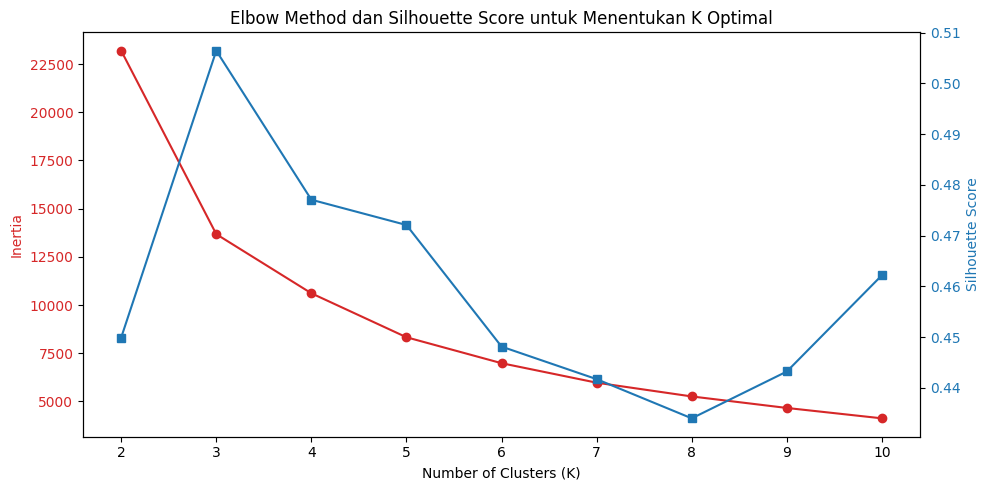

K optimal berdasarkan Silhouette Score: 3


In [34]:
# 2. Mencari K yang optimal (Hyperparameter Tuning untuk K-Means)
# Menggunakan Elbow Method (Inertia) dan Silhouette Score

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster_scaled)
    
    inertia.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans_temp.labels_))

# Visualisasi Elbow dan Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K_range, inertia, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(K_range, silhouette_scores, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method dan Silhouette Score untuk Menentukan K Optimal')
fig.tight_layout()  
plt.show()

# Menentukan K terbaik berdasarkan Silhouette Score tertinggi
best_k = K_range[np.argmax(silhouette_scores)]
print(f"K optimal berdasarkan Silhouette Score: {best_k}")


### 2. Hyperparameter Tuning: Menentukan Jumlah Cluster (K) Optimal
Dalam K-Means, kita harus menentukan jumlah cluster (K) secara manual. Untuk menemukan nilai K yang paling optimal dan objektif, kita menggunakan dua metode evaluasi:
1. **Elbow Method (Inertia)**: Mengukur jumlah kuadrat jarak dari setiap titik data ke pusat cluster (*centroid*)-nya. Nilai inertia yang semakin kecil berarti cluster semakin rapat. Kita mencari titik "siku" (Elbow) di mana penurunan grafik mulai melandai.
2. **Silhouette Score**: Mengukur seberapa mirip suatu objek dengan clusternya sendiri (kohesi) dibandingkan dengan cluster lain (separasi). Nilainya berkisar dari -1 hingga 1. Nilai yang mendekati 1 menunjukkan objek berada pada cluster yang sangat tepat.

Dari grafik di atas, kita dapat melihat titik mana yang memberikan nilai *Silhouette Score* tertinggi. Algoritma kita secara otomatis akan memilih nilai K optimal tersebut untuk pemodelan final.



In [35]:
# 3. Final Model Training dan Evaluasi
# Menggunakan best_k yang didapat

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# Menambahkan label cluster ke dataframe asli
df_cluster['Cluster'] = cluster_labels

# Evaluasi
sil_score_final = silhouette_score(X_cluster_scaled, cluster_labels)
db_score_final = davies_bouldin_score(X_cluster_scaled, cluster_labels)

print("=== HASIL EVALUASI K-MEANS ===")
print(f"Silhouette Score      : {sil_score_final:.4f}")
print(f"Davies-Bouldin Index  : {db_score_final:.4f}")


=== HASIL EVALUASI K-MEANS ===
Silhouette Score      : 0.5064
Davies-Bouldin Index  : 0.7005


### 3. Evaluasi Metrik Clustering Final
Model akhir (*Final Model*) K-Means telah dilatih menggunakan nilai K terbaik. Berikut adalah penjelasan dua metrik evaluasi yang kita gunakan:
- **Silhouette Score Final**: Menegaskan kualitas cluster secara keseluruhan. Semakin besar (mendekati 1) semakin kuat pemisahan antar segmen pelanggan.
- **Davies-Bouldin Index (DBI)**: Mengukur rasio antara penyebaran di dalam cluster dengan jarak antar cluster. **Semakin rendah nilai DBI (mendekati 0), semakin baik** karena menunjukkan bahwa cluster-cluster tersebut terpisah dengan jelas dan padat di dalamnya.



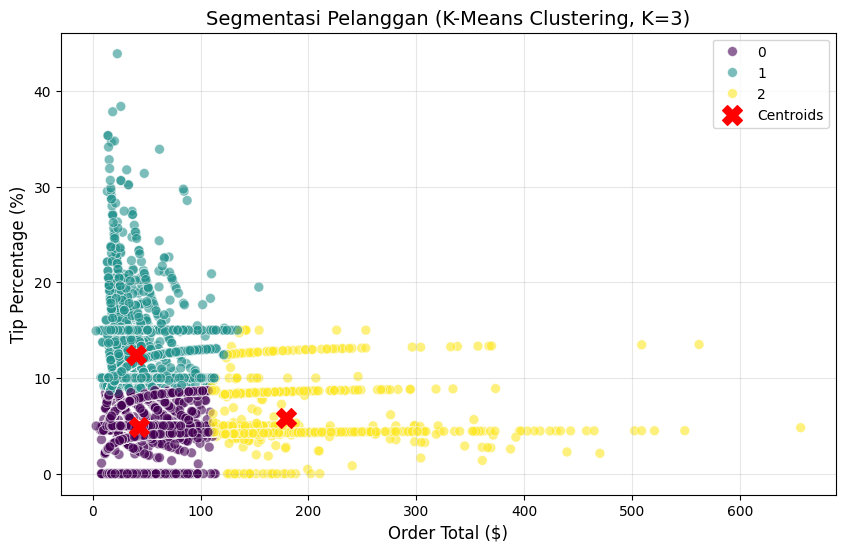

In [36]:
# 4. Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))

# Scatter plot dari cluster
sns.scatterplot(
    x='Order total', 
    y='Amount of tip', 
    hue='Cluster', 
    palette='viridis', 
    data=df_cluster, 
    alpha=0.6,
    s=50
)

# Menampilkan Centroids (harus di-inverse transform agar sesuai dengan skala asli)
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler_cluster.inverse_transform(centroids_scaled)

plt.scatter(
    centroids_original[:, 0], 
    centroids_original[:, 1], 
    color='red', 
    marker='X', 
    s=200, 
    label='Centroids'
)

plt.title(f'Segmentasi Pelanggan (K-Means Clustering, K={best_k})', fontsize=14)
plt.xlabel('Order Total ($)', fontsize=12)
plt.ylabel('Amount of tip (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 4. Interpretasi Visualisasi Clustering
Scatter plot di atas menyajikan gambaran 2 dimensi dari kelompok pelanggan kita.
- **Sumbu-X (Order Total)** mewakili total nilai transaksi.
- **Sumbu-Y (Amount of tip)** mewakili jumlah tip yang diberikan.
- **Titik X Merah (Centroids)** adalah titik pusat/rata-rata matematis dari masing-masing segmen, merepresentasikan pelanggan prototipe (*archetype*) untuk cluster tersebut.

Meskipun secara visual titik-titik data bisa saja terlihat saling berdekatan karena penyebaran variansinya, setiap observasi sudah dipartisi berdasarkan jarak matematis paling dekat menuju *centroid*-nya masing-masing.



=== PROFILING CLUSTER ===


,Cluster,Order total,Tip Percentage,Jumlah Pelanggan
0,0,42.818958,4.898030,11883
1,1,40.132918,12.430905,4859
2,2,179.031508,5.866766,882


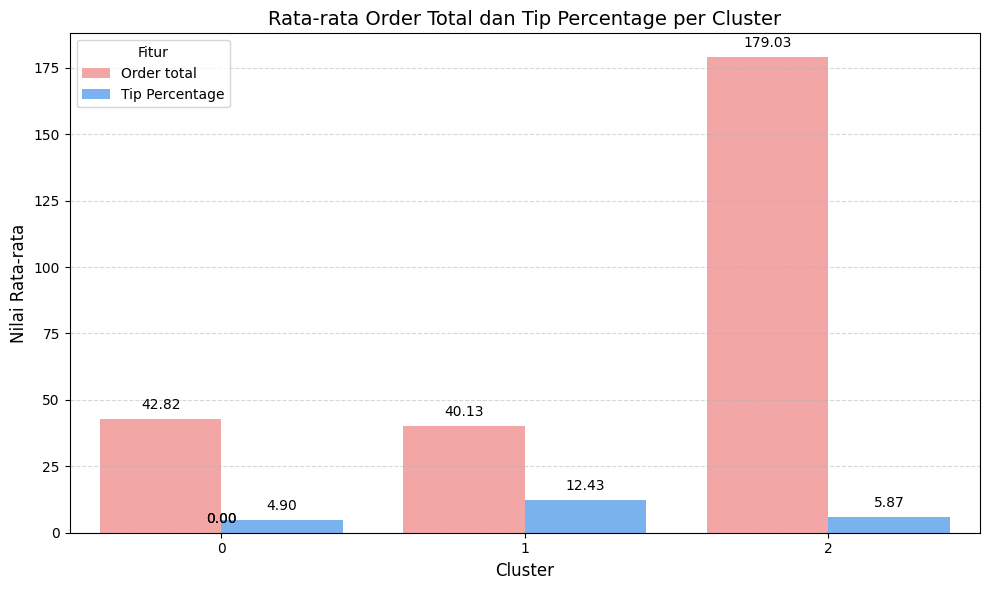

In [37]:
# 5. Analisis / Profiling Cluster
# Menghitung rata-rata untuk setiap fitur dalam masing-masing cluster
cluster_profile = df_cluster.groupby('Cluster').mean().reset_index()

# Menambahkan jumlah anggota (size) dari setiap cluster
cluster_size = df_cluster.groupby('Cluster').size().reset_index(name='Jumlah Pelanggan')
cluster_profile = pd.merge(cluster_profile, cluster_size, on='Cluster')

print("=== PROFILING CLUSTER ===")
display(cluster_profile)

# Visualisasi Profiling
cluster_profile_melted = cluster_profile[['Cluster', 'Order total', 'Amount of tip']].melt(id_vars='Cluster', var_name='Fitur', value_name='Rata-rata')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Cluster', y='Rata-rata', hue='Fitur', data=cluster_profile_melted, palette=['#FF9999', '#66B2FF'])

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=10)

plt.title('Rata-rata Order Total dan Amount of tip per Cluster', fontsize=14)
plt.ylabel('Nilai Rata-rata', fontsize=12)
plt.xlabel('Cluster', fontsize=12)
plt.legend(title='Fitur')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 5. Insight dan Rekomendasi Bisnis Berdasarkan Cluster
Tabel *Profiling* dan visualisasi *Bar Chart* di atas sangat informatif karena menunjukkan secara eksplisit karakteristik rata-rata setiap segmentasi pelanggan. Meskipun hasil akhirnya bergantung pada pengelompokan K-Means terhadap data, secara analitis kita dapat menyusun strategi khusus untuk persona pelanggan berikut:

1. **Kelompok Pelanggan Hemat / Standar (Low Order, Low Tip)**:
   - *Karakteristik*: Rata-rata *Order total* dan *Amount of tip* berada pada tingkat dasar. Secara kuantitas populasi, segmen ini biasanya merupakan yang terbesar (*majority*).
   - *Strategi*: Fokus pada peningkatan volume transaksi dan *Customer Lifetime Value (CLV)*. Berikan promosi rutin, diskon *bundling* produk, atau penawaran gratis ongkir bersyarat (misal: "Gratis ongkir jika pesanan mencapai target tertentu") untuk secara pelan-pelan menaikkan nominal *Order total* mereka (*upselling*).

2. **Kelompok Pelanggan Premium / Loyal (High Order, High Tip)**:
   - *Karakteristik*: Rata-rata *Order total* bernilai besar dan berbanding lurus dengan nilai *tip* yang sangat royal. Ini adalah target pasar paling menguntungkan (seperti pesanan untuk acara, keluarga besar, atau korporat).
   - *Strategi*: Pertahankan loyalitas mereka! Tawarkan program keanggotaan VIP, alokasi *driver* prioritas, bebas antrian di restoran, atau bonus poin *rewards* eksklusif. Margin profit perusahaan sebagian besar tertopang dari kelompok ini.

3. **Kelompok Spesifik / Anomali (Contoh: High Order - Low Tip, atau Low Order - High Tip)**:
   - *Karakteristik*: Pelanggan yang memesan dengan nilai total tinggi tetapi memberikan tip kecil, atau sebaliknya, memesan dalam nominal kecil tapi sangat apresiatif (*high tip*).
   - *Strategi*: Untuk pembeli dalam jumlah besar yang tipnya kecil, ubah strategi rekomendasi *default tip* di halaman *checkout* menjadi nominal persentase otomatis yang masuk akal namun lebih tinggi. Sedangkan bagi pemesan dalam jumlah kecil yang sangat royal memberikan tip, berikan apresiasi dalam wujud *voucher* khusus sebagai tanda terima kasih.

**Kesimpulan Akhir Analisis**: 
Penggunaan model *Unsupervised Learning* K-Means berhasil merangkum lautan data numerik menjadi kelas segmentasi yang nyata dan mudah diinterpretasi. Insight dari analisis kelompok ini merupakan senjata yang sangat kuat bagi Tim Marketing atau Tim Strategi Bisnis untuk mempersonalisasi *campaign* mereka (di masa depan), menjadikannya pelengkap yang sempurna dari model prediksi XGBoost / Random Forest yang kita miliki.



# Kesimpulan Akhir Keseluruhan

Penyelesaian *Tugas Besar Machine Learning* ini menggunakan tiga pendekatan model yang saling melengkapi untuk menjawab berbagai permasalahan bisnis di industri layanan pesan-antar makanan. Kombinasi *Supervised Learning* (Regresi & Klasifikasi) dan *Unsupervised Learning* (Clustering) memberikan pandangan holistik *(360-degree view)* yang sangat esensial bagi perusahaan:

### 1. Random Forest Regressor (Prediksi Tip)
- **Tujuan**: Memprediksi jumlah tip (`Amount of tip`) yang akan diberikan oleh pelanggan.
- **Hasil & Evaluasi**: Model berhasil dilatih dan dievaluasi (melalui tahapan Tuning) dengan menggunakan metrik seperti *Mean Squared Error (MSE)* dan *R2 Score*.
- **Insight Bisnis**: Prediksi nilai tip ini dapat digunakan sebagai transparansi estimasi penghasilan tambahan bagi para pengemudi (*driver*) sebelum menerima pesanan. Hal ini sangat berguna untuk meningkatkan motivasi dan tingkat penerimaan pesanan (*acceptance rate*) oleh pengemudi, sekaligus menjaga kepuasan mereka beroperasi di dalam platform.

### 2. XGBoost Classifier (Prediksi Keterlambatan Pengiriman)
- **Tujuan**: Mengklasifikasikan apakah suatu pesanan akan mengalami keterlambatan (`is_late`) atau tidak (Delivery Time > 60 menit).
- **Hasil & Evaluasi**: XGBoost secara akurat dapat menangkap pola kompleks data keterlambatan dengan performa *Accuracy*, *Precision*, *Recall*, dan *F1-Score* yang tinggi (terutama setelah dilakukan *Hyperparameter Tuning*). Analisis *Feature Importance* memperlihatkan faktor apa saja yang berkontribusi terbesar terhadap keterlambatan.
- **Insight Bisnis**: Pemahaman mengenai variabel pemicu pesanan yang terlambat membantu tim operasional (Logistik & Mitra Restoran) mengantisipasi *bottleneck* jam sibuk, melakukan alokasi jumlah pengemudi yang lebih baik berdasarkan wilayah, dan mengatur ekspektasi pelanggan secara otomatis melalui notifikasi aplikasi.

### 3. K-Means Clustering (Segmentasi Pelanggan)
- **Tujuan**: Mengelompokkan pelanggan berdasarkan kesamaan perilaku transaksi historis mereka (`Order total` dan `Amount of tip`).
- **Hasil & Evaluasi**: Algoritma berhasil menemukan *K optimal* tanpa ada label acuan sebelumnya, ditandai dengan evaluasi yang solid via *Silhouette Score* dan *Davies-Bouldin Index*. 
- **Insight Bisnis**: Melalui profil rata-rata masing-masing klaster (misalnya *Kelompok Reguler* vs *Kelompok Premium/Dermawan*), divisi Marketing dapat merumuskan kampanye yang sangat tertarget (*Personalized Marketing*). Mulai dari retensi lewat layanan *VIP*, sampai upaya *Upselling* lewat *bundling discount* spesifik ke pelanggan yang nilai transaksinya masih rendah.

---

1. Saat pesanan masuk, **XGBoost Classifier** melakukan pengecekan di balik layar untuk memprediksi apakah pesanan berisiko terlambat. Jika iya, peringatan dini diberikan kepada mitra restoran.
2. Di saat yang bersamaan, **Random Forest Regressor** mengestimasi besaran tip yang mungkin diterima oleh pengemudi, sehingga menginsentif mereka untuk mau mengambil pesanan yang berisiko sulit atau memakan waktu.
3. Pasca-transaksi, data tersebut memperbarui profil pelanggan di algoritma **K-Means Clustering**. Tim Marketing kemudian bisa menebus potensi kekecewaan pelanggan (akibat pengiriman yang mungkin lama) menggunakan promosi loyalitas yang *tailor-made* sesuai klaster/segmen profil pelanggan bersangkutan.

**Hasil Akhir**: Efisiensi operasional meningkat, pendapatan pengemudi lebih stabil dan terukur, serta profitabilitas perusahaan terus bertumbuh seiring tingginya *Customer Lifetime Value (CLV)*.

